# 効率的フロンティア（Markowitz MPT）

Markowitzの現代ポートフォリオ理論（MPT）をPythonで実装。
3銘柄（エヌビディア、エクソンモービル、ジョンソン＆ジョンソン）を使って効率的フロンティアとタンジェンシーポートフォリオを描画する。
コードはFinancial Investmentの授業で習得した。

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from itertools import product
from itertools import combinations_with_replacement
from math import comb

In [16]:
#パラメータの設定
tickers = ['NVDA', 'XOM', 'JNJ']
start, end = '2018-01-01', '2025-12-31'
rf = 0.0

In [17]:
#データ取得
px = yf.download(tickers, start=start, end=end)['Close']
px_m = px.resample('ME').last()
ret_m = px_m.pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


In [18]:
mu = (ret_m.mean()*12).to_numpy()
Sigma = (ret_m.cov()*12).to_numpy()
names = ret_m.columns.tolist()
n = len(names)

In [19]:
def weight_grid_df(n: int, step: float) -> pd.DataFrame:

    m = int(round(1.0/step))

    if abs(m*step - 1.0) > 1e-12:
        raise ValueError("`step` must divide 1 exactly (e.g., 0.01, 0.02, 0.05).")
    if n < 2:
        raise ValueError("n must be >= 2.")

    # All combinations
    K = comb(m + n - 1, n - 1)  # = C(m+n-1, n-1)
    w_vec = np.empty((K, n), dtype=float)

    i = 0
    for picks in combinations_with_replacement(range(n), m):
        cnt = np.bincount(picks, minlength=n)
        w_vec[i] = cnt / m
        i += 1

    return w_vec

In [ ]:
#Grid Search
step = 0.01
w_vec = weight_grid_df(n, step)

rets = w_vec @ mu
vols = np.sqrt(np.diag(w_vec @ Sigma @ w_vec.T))
sharpes = (rets-rf)/vols

dfp = pd.DataFrame({
    'return': rets,
    'risk': vols,
    'sharpe':sharpes,
    'weights':w_vec.tolist()
})

In [21]:
#Efficient Frontier
df_sorted = dfp.sort_values('risk')
cummax_ret = df_sorted['return'].cummax()
frontier = df_sorted[np.isclose(df_sorted['return'], cummax_ret, atol = 1e-12)]

In [22]:
#Tangency Portforio
tan = dfp.loc[dfp['sharpe'].idxmax()]
w_tan = np.array(tan['weights'], dtype=float)
ret_tan, vol_tan, shp_tan = tan['return'], tan['risk'], tan['sharpe']

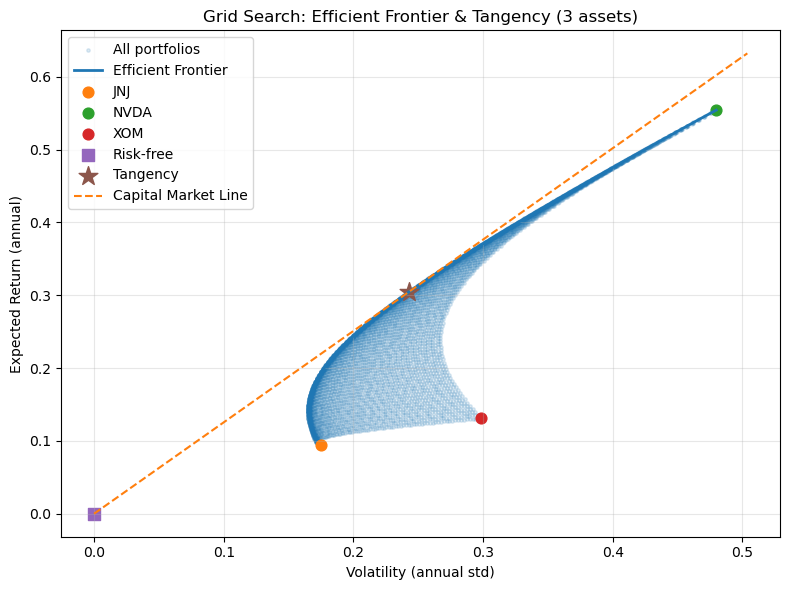

=== Tangency (weights) ===
JNJ       : 0.460
NVDA      : 0.450
XOM       : 0.090
Return: 30.47%, Vol: 24.28%, Sharpe: 1.255, rf=0.00%


In [25]:
#Plot the results
plt.figure(figsize=(8,6))

# All candidate portfolios (light gray cloud)
plt.scatter(dfp["risk"], dfp["return"], s=6, alpha=0.15, label="All portfolios")

# Efficient frontier
plt.plot(frontier["risk"], frontier["return"], lw=2, label="Efficient Frontier")

# Individual assets
for i in range(len(names)):
    plt.scatter(np.sqrt(Sigma[i,i]), mu[i], s=60, label=names[i])

# Risk-free asset and tangency portfolio
plt.scatter(0, rf, marker="s", s=80, label="Risk-free")
plt.scatter(vol_tan, ret_tan, marker="*", s=200, label="Tangency")

# Capital Market Line (CML)
x = np.linspace(0, max(frontier["risk"].max(), vol_tan)*1.05, 100)
y = rf + shp_tan * x
plt.plot(x, y, "--", label="Capital Market Line")

plt.xlabel("Volatility (annual std)")
plt.ylabel("Expected Return (annual)")
plt.title("Grid Search: Efficient Frontier & Tangency (3 assets)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Tangency (weights) ===")
w_tan = np.array(w_tan).flatten()  # turns [[0.3],[0.4],[0.3]] → [0.3,0.4,0.3]
for nm, w in zip(names, w_tan):
    print(f"{nm:10s}: {w:.3f}")
print(f"Return: {ret_tan:.2%}, Vol: {vol_tan:.2%}, Sharpe: {shp_tan:.3f}, rf={rf:.2%}")